Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
Extracted Files: ['plantvillage', 'PlantVillage']
Available directories: ['plantvillage', 'PlantVillage']
Found 33022 images belonging to 2 classes.
Found 8254 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 205s 194ms/step - accuracy: 0.4977 - loss: 0.7151 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 194s 188ms/step - accuracy: 0.4918 - loss: 0.6932 - val_accuracy: 0.4994 - val_loss: 0.6932
Epoch 3/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 196s 190ms/step - accuracy: 0.4929 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 201s 194ms/step - accuracy: 0.5052 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 192s 186ms/step - accuracy: 0.5027 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 192s 186ms/step - accuracy: 0.5007 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 7/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 191s 185ms/step - accuracy: 0.5018 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 195s 189ms/step - ac

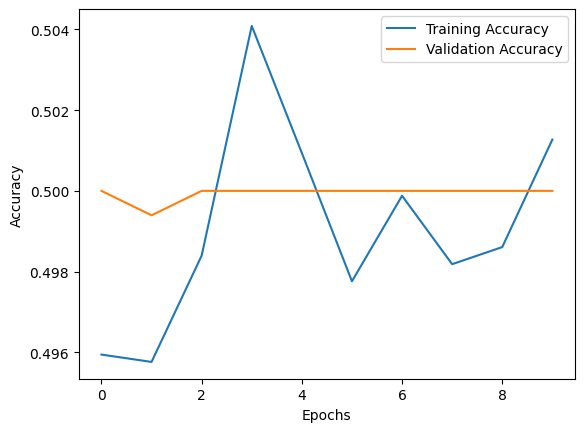

Model saved as plant_disease_model.h5


In [ ]:
!pip install kaggle tensorflow numpy pandas matplotlib seaborn

# Upload kaggle.json API Key
from google.colab import files
import os
files.upload()

# Move kaggle.json to the correct directory
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download Plant Disease Dataset (PlantVillage)
!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip -d plant_disease_data

# Verify dataset extraction
import os
print("Extracted Files:", os.listdir("plant_disease_data"))

# Import necessary libraries
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define dataset path (within Colab environment)
data_dir = 'plant_disease_data/'

# Check actual dataset folders
print("Available directories:", os.listdir(data_dir))

# Data Preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# Define CNN Model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(len(train_generator.class_indices), activation='softmax')
])

# Compile the Model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train the Model
epochs = 10
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs
)

# Evaluate Model
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Save Model (within Colab environment)
model.save('plant_disease_model.h5')
print('Model saved as plant_disease_model.h5')